# Customer Churn Prediction

## Project Overview

This project develops a machine learning system to predict whether a telecommunications customer is likely to churn.

The project combines exploratory data analysis, data preprocessing, feature engineering, classification models, cross-validation, hyperparameter tuning, and model evaluation.

The final goal is not only to predict churn, but also to identify customer characteristics associated with churn and translate the findings into actionable retention strategies.

## Objectives

- Understand the characteristics of telecom customers
- Analyze patterns associated with customer churn
- Clean and preprocess customer data
- Engineer useful features
- Build classification models
- Compare multiple machine learning algorithms
- Perform cross-validation
- Tune the best-performing model
- Evaluate the final model using multiple metrics
- Generate business recommendations

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Basic libraries imported!")

Basic libraries imported!


In [127]:
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance

print("Machine learning libraries imported!")

Machine learning libraries imported!


In [128]:
df = pd.read_csv(
    "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [129]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [131]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [132]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [133]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


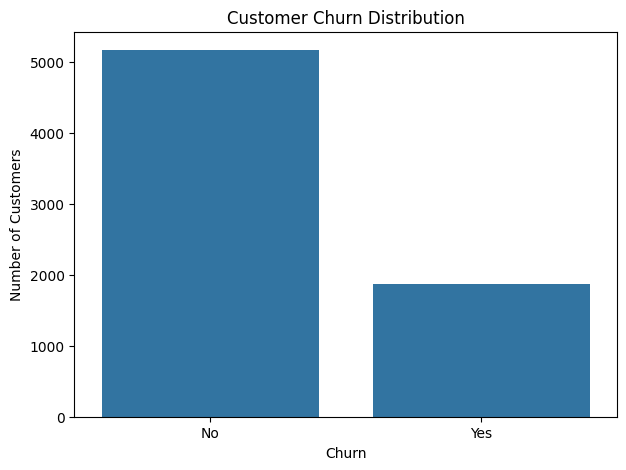

In [134]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [135]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0


In [136]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [137]:
print("Duplicate CustomerID:", df["customerID"].duplicated().sum())

Duplicate CustomerID: 0


In [138]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [139]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [140]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [141]:
df["Churn"] = (
    df["Churn"]
    .map({
        "Yes": 1,
        "No": 0
    })
)

In [142]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


Apakah tipe kontrak berkaitan dengan kemungkinan pelanggan churn?

In [143]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .mean()
    .sort_values(ascending=False)
)

contract_churn

,Churn
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


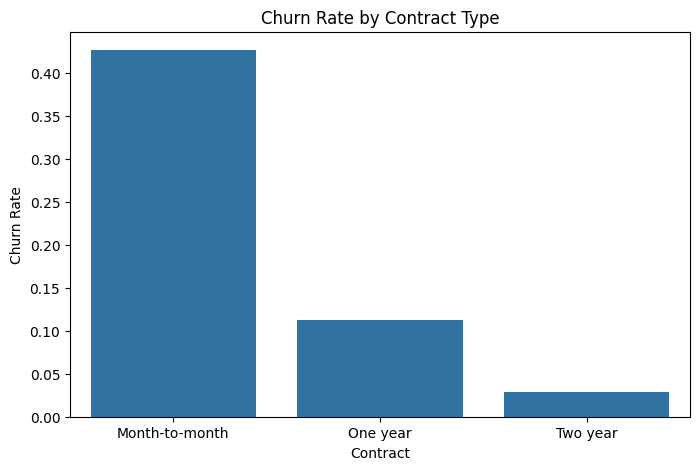

In [144]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn Rate")

plt.show()

Apakah pelanggan yang churn cenderung memiliki tenure lebih pendek?

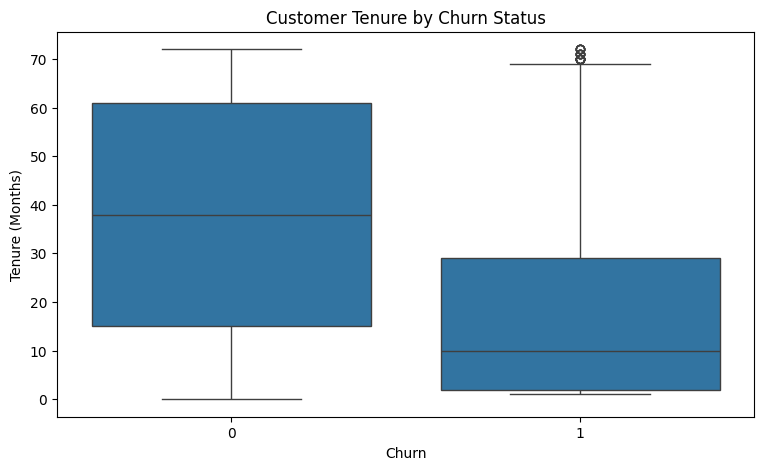

In [145]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

Churn berdasarkan MonthlyCharges

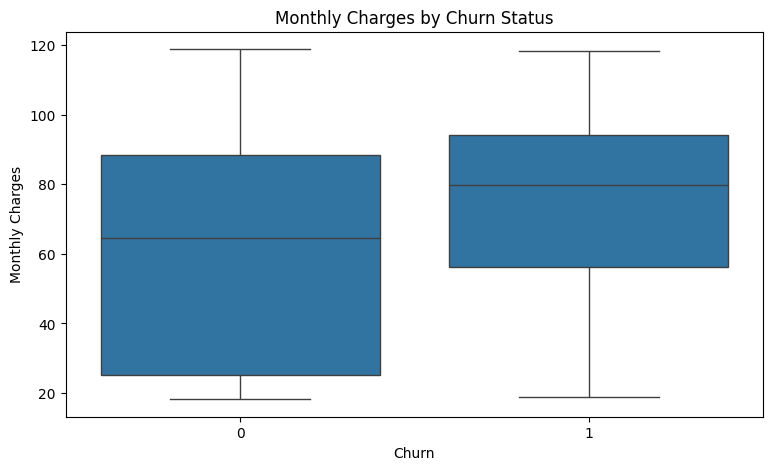

In [146]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

Churn berdasarkan Internet Service

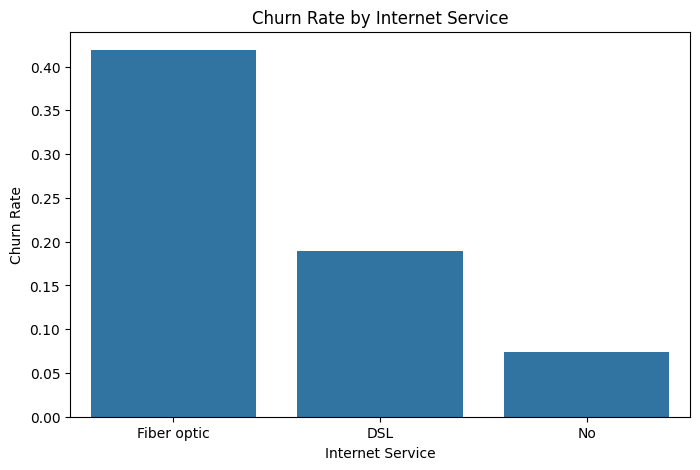

In [147]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
    .mean()
    .sort_values(ascending=False)
)

internet_churn
plt.figure(figsize=(8, 5))

sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")

plt.show()

In [148]:
df["AvgMonthlyValue"] = (
    df["TotalCharges"] /
    df["tenure"].replace(0, np.nan)
)

In [149]:
df["AvgMonthlyValue"] = df["AvgMonthlyValue"].fillna(
    df["MonthlyCharges"]
)

In [150]:
X = df.drop(
    columns=["Churn", "customerID"]
)

y = df["Churn"]

In [151]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 20)
Target: (7043,)


In [152]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numeric features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyValue']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [153]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [154]:
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (5634, 20)
Testing : (1409, 20)


In [155]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [156]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [157]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [158]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

In [159]:
logistic_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'AvgMonthlyValue'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [160]:
y_pred = logistic_pipeline.predict(X_test)

y_prob = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

In [161]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.8062
Precision: 0.6583
Recall   : 0.5615
F1-Score : 0.6061
ROC-AUC  : 0.8419


In [162]:
df.shape

(7043, 22)

In [163]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [164]:
missing_values[missing_values > 0]

,0


In [165]:
contract_churn

,Churn
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


In [166]:
internet_churn

,Churn
InternetService,
Fiber optic,0.418928
DSL,0.189591
No,0.074050


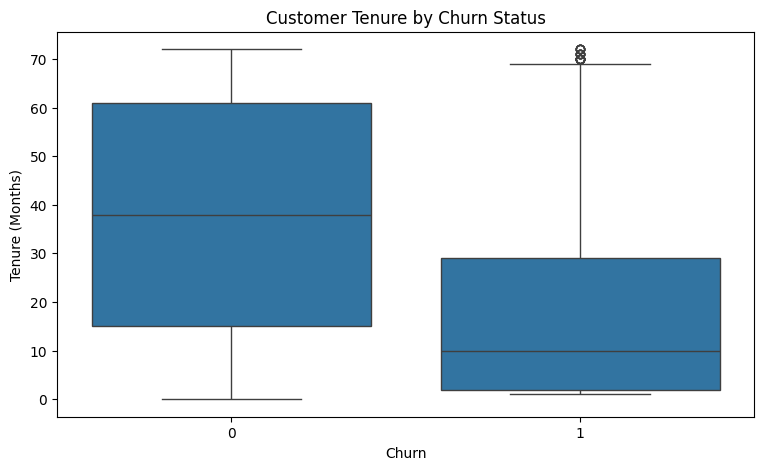

In [167]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

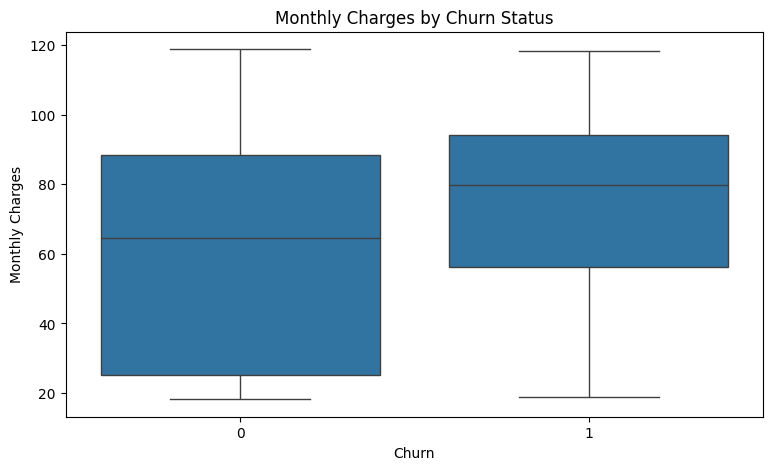

In [168]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [169]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .mean()
    .sort_values(ascending=False)
)

payment_churn

,Churn
PaymentMethod,
Electronic check,0.452854
Mailed check,0.191067
Bank transfer (automatic),0.167098
Credit card (automatic),0.152431


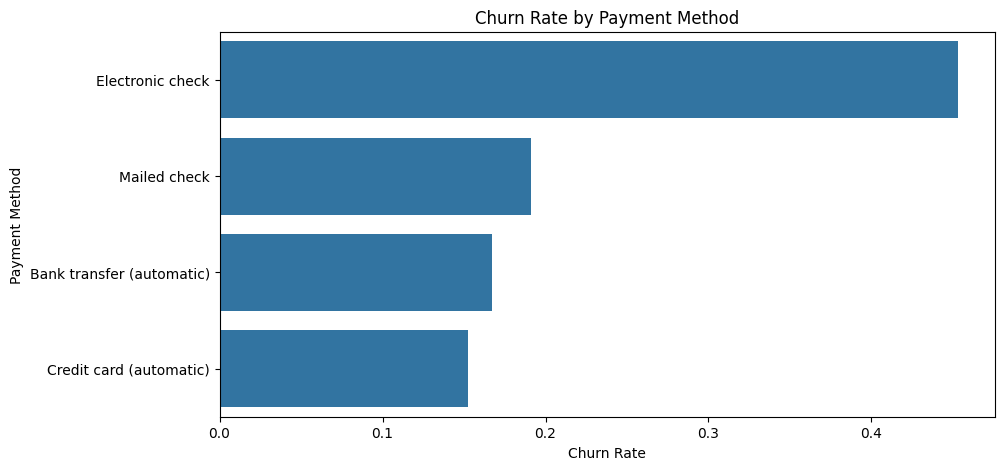

In [170]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=payment_churn.values,
    y=payment_churn.index
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate")
plt.ylabel("Payment Method")

plt.show()

In [171]:
senior_churn = (
    df.groupby("SeniorCitizen")["Churn"]
    .mean()
)

senior_churn

,Churn
SeniorCitizen,
0,0.236062
1,0.416813


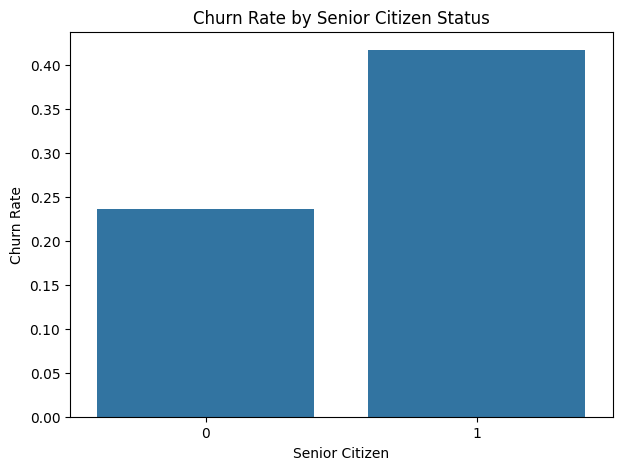

In [172]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=senior_churn.index,
    y=senior_churn.values
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate")

plt.show()

In [173]:
df["AvgMonthlyValue"] = (
    df["TotalCharges"] /
    df["tenure"].replace(0, np.nan)
)

df["AvgMonthlyValue"] = df["AvgMonthlyValue"].fillna(
    df["MonthlyCharges"]
)

df[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AvgMonthlyValue"
]].head()

,tenure,MonthlyCharges,TotalCharges,AvgMonthlyValue
0,1,29.85,29.85,29.850000
1,34,56.95,1889.50,55.573529
2,2,53.85,108.15,54.075000
3,45,42.30,1840.75,40.905556
4,2,70.70,151.65,75.825000


In [174]:
def tenure_group(months):
    if months <= 12:
        return "New"
    elif months <= 36:
        return "Mid"
    else:
        return "Long-term"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

In [175]:
df["TenureGroup"].value_counts()

,count
TenureGroup,
Long-term,3001
New,2186
Mid,1856


In [176]:
tenure_group_churn = (
    df.groupby("TenureGroup")["Churn"]
    .mean()
    .sort_values(ascending=False)
)

tenure_group_churn

,Churn
TenureGroup,
New,0.474382
Mid,0.255388
Long-term,0.119294


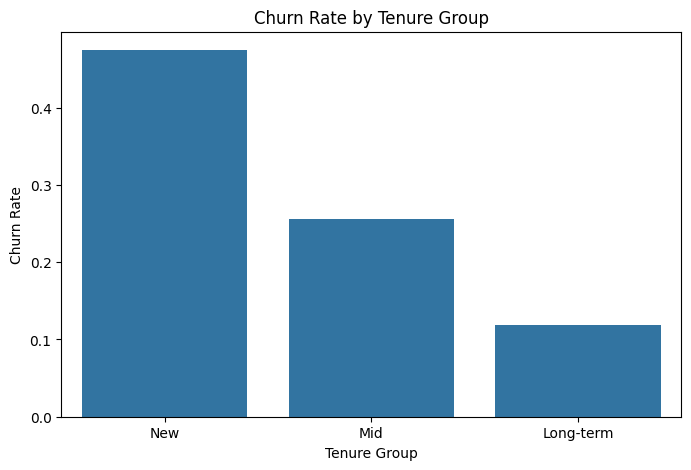

In [177]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=tenure_group_churn.index,
    y=tenure_group_churn.values
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate")

plt.show()

In [178]:
X = df.drop(
    columns=["Churn", "customerID"]
)

y = df["Churn"]

In [179]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric:", numeric_features)
print("\nCategorical:", categorical_features)

Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyValue']

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


In [180]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (5634, 21)
Testing : (1409, 21)


In [181]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [182]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'AvgMonthlyValue']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [183]:
y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

In [184]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.8006
Precision: 0.6535
Recall   : 0.5294
F1-Score : 0.5849
ROC-AUC  : 0.8419


In [185]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [186]:
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'AvgMonthlyValue']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup'])])),
                ('model',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [187]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 1]

In [188]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

Accuracy : 0.7786
Precision: 0.6054
Recall   : 0.4759
F1-Score : 0.5329
ROC-AUC  : 0.8254


In [189]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1035
           1       0.61      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



In [190]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1": [
        f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.800568,0.653465,0.529412,0.584934,0.841853
1,Random Forest,0.778566,0.605442,0.475936,0.532934,0.825428


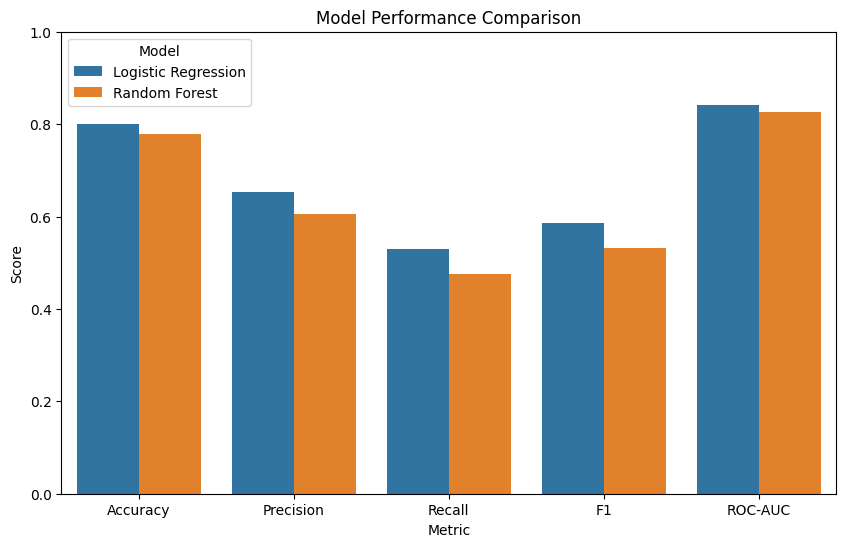

In [191]:
plt.figure(figsize=(10, 6))

comparison_melted = model_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.ylabel("Score")

plt.show()

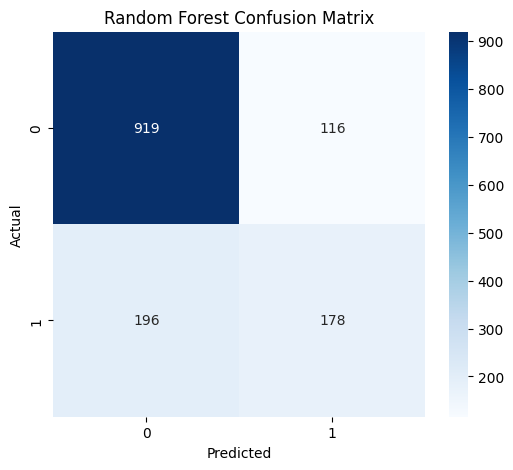

In [192]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [193]:
!pip install xgboost -q

In [194]:
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

In [195]:
xgb_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'AvgMonthlyValue']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unk...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [196]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:, 1]

In [197]:
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb
)

xgb_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")

Accuracy : 0.7991
Precision: 0.6564
Recall   : 0.5107
F1-Score : 0.5744
ROC-AUC  : 0.8416


In [198]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [199]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall
    ],
    "F1": [
        f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_auc,
        xgb_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.800568,0.653465,0.529412,0.584934,0.841853
1,Random Forest,0.778566,0.605442,0.475936,0.532934,0.825428
2,XGBoost,0.799148,0.656357,0.510695,0.574436,0.841564


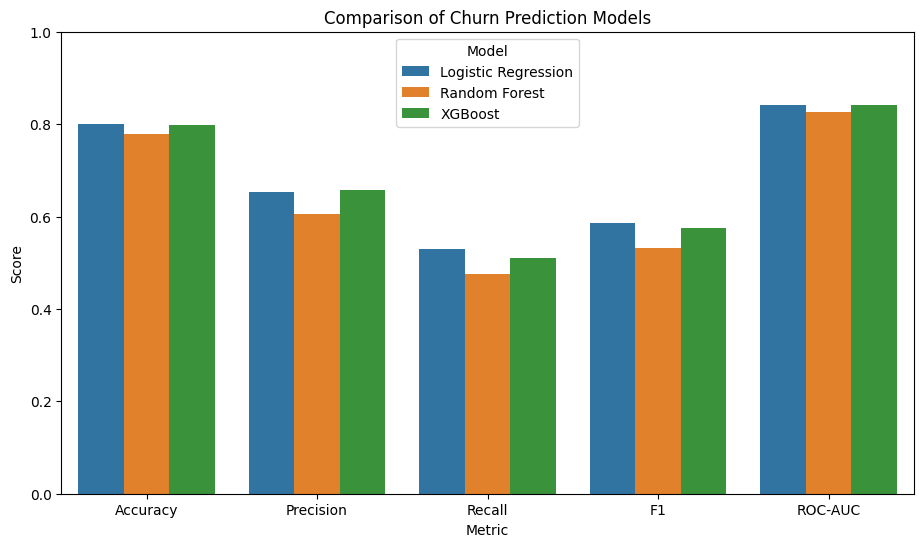

In [200]:
plt.figure(figsize=(11, 6))

comparison_melted = model_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.ylim(0, 1)
plt.title("Comparison of Churn Prediction Models")
plt.ylabel("Score")

plt.show()

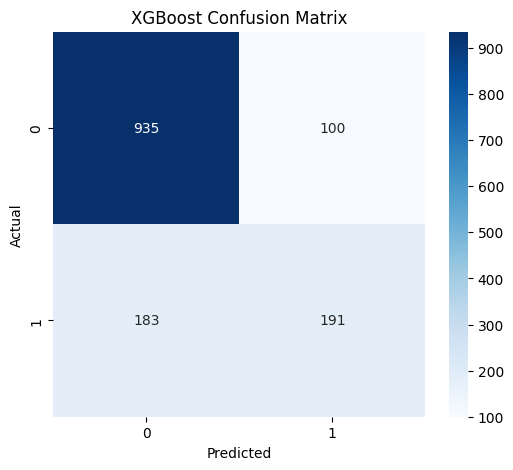

In [201]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [202]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [203]:
cv_results = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

In [204]:
print("Cross Validation Results")

for metric in [
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_roc_auc"
]:
    print(
        f"{metric.replace('test_', '').title():10s}: "
        f"{cv_results[metric].mean():.4f} ± "
        f"{cv_results[metric].std():.4f}"
    )

Cross Validation Results
Accuracy  : 0.8048 ± 0.0074
Precision : 0.6663 ± 0.0202
Recall    : 0.5304 ± 0.0273
F1        : 0.5902 ± 0.0192
Roc_Auc   : 0.8472 ± 0.0109


In [205]:
logistic_tuning = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

In [206]:
param_grid = {
    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],
    "model__class_weight": [
        None,
        "balanced"
    ]
}

In [207]:
grid_search = GridSearchCV(
    estimator=logistic_tuning,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [208]:
grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges',
                                                                          'AvgMonthlyValue']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('im...
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod',
                                                                          'TenureGroup'])])),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__class_weight': [None, 'balanced']},
             scoring='roc_auc', verbose=1)

In [209]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'model__C': 10, 'model__class_weight': None}

Best CV ROC-AUC:
0.8473490623157011


In [210]:
best_model = grid_search.best_estimator_

In [211]:
y_pred_tuned = best_model.predict(X_test)

y_prob_tuned = best_model.predict_proba(
    X_test
)[:, 1]

In [212]:
tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

tuned_precision = precision_score(
    y_test,
    y_pred_tuned
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned
)

tuned_auc = roc_auc_score(
    y_test,
    y_prob_tuned
)

print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1-Score : {tuned_f1:.4f}")
print(f"ROC-AUC  : {tuned_auc:.4f}")

Accuracy : 0.8020
Precision: 0.6547
Recall   : 0.5374
F1-Score : 0.5903
ROC-AUC  : 0.8409


In [213]:
tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

tuned_precision = precision_score(
    y_test,
    y_pred_tuned
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned
)

tuned_auc = roc_auc_score(
    y_test,
    y_prob_tuned
)

print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1-Score : {tuned_f1:.4f}")
print(f"ROC-AUC  : {tuned_auc:.4f}")

Accuracy : 0.8020
Precision: 0.6547
Recall   : 0.5374
F1-Score : 0.5903
ROC-AUC  : 0.8409


In [214]:
print(
    classification_report(
        y_test,
        y_pred_tuned
    )
)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [215]:
y_prob = best_model.predict_proba(X_test)[:, 1]

In [216]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]

In [217]:
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results

,Threshold,Precision,Recall,F1
0,0.30,0.520522,0.745989,0.613187
1,0.35,0.544118,0.692513,0.609412
2,0.40,0.578947,0.647059,0.611111
3,0.45,0.601648,0.585561,0.593496
4,0.50,0.654723,0.537433,0.590308


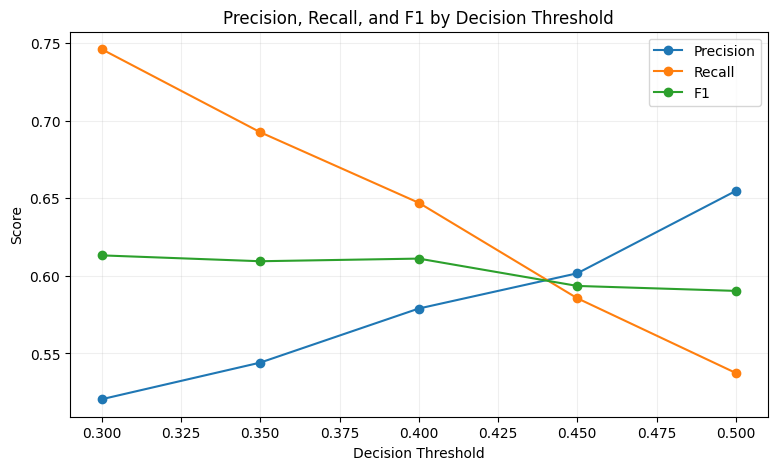

In [218]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 by Decision Threshold")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [219]:
final_threshold = 0.30

y_pred_final = (
    y_prob >= final_threshold
).astype(int)

In [220]:
final_precision = precision_score(
    y_test,
    y_pred_final
)

final_recall = recall_score(
    y_test,
    y_pred_final
)

final_f1 = f1_score(
    y_test,
    y_pred_final
)

final_accuracy = accuracy_score(
    y_test,
    y_pred_final
)

print(f"Final Threshold : {final_threshold}")
print(f"Accuracy        : {final_accuracy:.4f}")
print(f"Precision       : {final_precision:.4f}")
print(f"Recall          : {final_recall:.4f}")
print(f"F1-Score        : {final_f1:.4f}")

Final Threshold : 0.3
Accuracy        : 0.7502
Precision       : 0.5205
Recall          : 0.7460
F1-Score        : 0.6132


In [221]:
print(
    classification_report(
        y_test,
        y_pred_final
    )
)

              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1035
           1       0.52      0.75      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



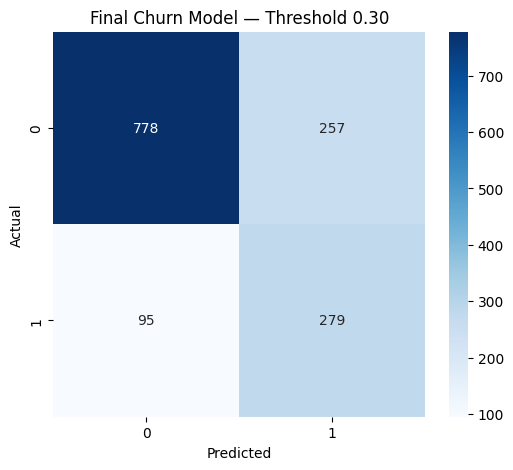

In [222]:
cm_final = confusion_matrix(
    y_test,
    y_pred_final
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Final Churn Model — Threshold 0.30")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [223]:
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [224]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
)

feature_importance

,Feature,Importance
4,tenure,0.179970
7,InternetService,0.118432
17,MonthlyCharges,0.118067
14,Contract,0.035892
13,StreamingMovies,0.018855
12,StreamingTV,0.017844
6,MultipleLines,0.008479
8,OnlineSecurity,0.007478
9,OnlineBackup,0.007181
11,TechSupport,0.007012


In [225]:
top_features = feature_importance.head(10)

top_features

,Feature,Importance
4,tenure,0.179970
7,InternetService,0.118432
17,MonthlyCharges,0.118067
14,Contract,0.035892
13,StreamingMovies,0.018855
12,StreamingTV,0.017844
6,MultipleLines,0.008479
8,OnlineSecurity,0.007478
9,OnlineBackup,0.007181
11,TechSupport,0.007012


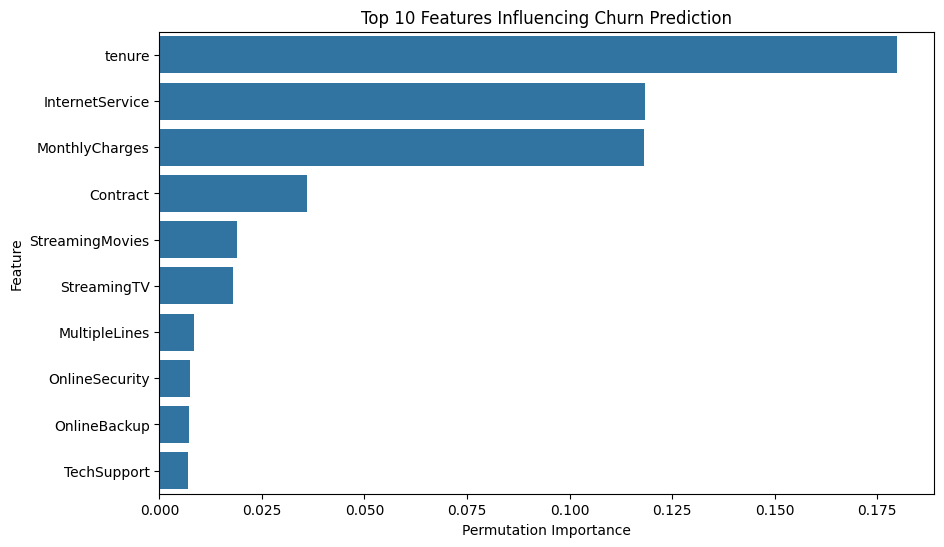

In [226]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Influencing Churn Prediction")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")

plt.show()

In [227]:
preprocessor_fitted = best_model.named_steps["preprocessor"]
logistic_fitted = best_model.named_steps["model"]

In [228]:
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

In [229]:
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

In [230]:
coefficients = logistic_fitted.coef_[0]

In [231]:
coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [232]:
top_positive = (
    coefficient_df
    .sort_values("Coefficient", ascending=False)
    .head(15)
)

top_positive

,Feature,Coefficient
17,cat__InternetService_Fiber optic,1.288758
37,cat__Contract_Month-to-month,0.572091
36,cat__StreamingMovies_Yes,0.520987
33,cat__StreamingTV_Yes,0.516022
15,cat__MultipleLines_Yes,0.351605
46,cat__TenureGroup_Long-term,0.325272
3,num__TotalCharges,0.282958
27,cat__DeviceProtection_Yes,0.226006
44,cat__PaymentMethod_Electronic check,0.161069
24,cat__OnlineBackup_Yes,0.149557


In [233]:
top_negative = (
    coefficient_df
    .sort_values("Coefficient", ascending=True)
    .head(15)
)

top_negative

,Feature,Coefficient
2,num__MonthlyCharges,-1.952253
1,num__tenure,-1.312118
16,cat__InternetService_DSL,-1.128951
39,cat__Contract_Two year,-0.841375
20,cat__OnlineSecurity_No internet service,-0.579743
23,cat__OnlineBackup_No internet service,-0.579743
18,cat__InternetService_No,-0.579743
26,cat__DeviceProtection_No internet service,-0.579743
32,cat__StreamingTV_No internet service,-0.579743
35,cat__StreamingMovies_No internet service,-0.579743


In [234]:
top_positive = (
    coefficient_df
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

top_negative = (
    coefficient_df
    .sort_values("Coefficient", ascending=True)
    .head(10)
)

coef_plot = pd.concat([
    top_negative,
    top_positive
])

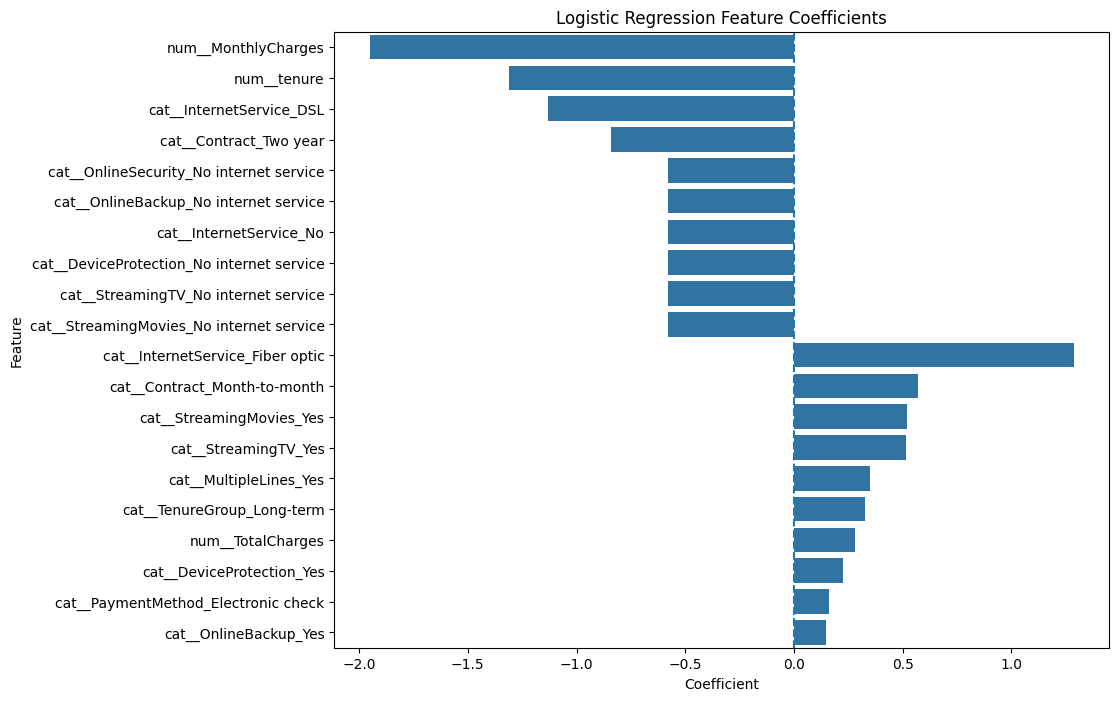

In [235]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=coef_plot,
    x="Coefficient",
    y="Feature"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

In [236]:
risk_df = X_test.copy()

risk_df["ActualChurn"] = y_test.values
risk_df["ChurnProbability"] = y_prob
risk_df["PredictedChurn"] = y_pred_final

In [237]:
def risk_category(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df["RiskLevel"] = (
    risk_df["ChurnProbability"]
    .apply(risk_category)
)

In [238]:
risk_distribution = (
    risk_df["RiskLevel"]
    .value_counts()
)

risk_distribution

,count
RiskLevel,
Low Risk,991
Medium Risk,300
High Risk,118


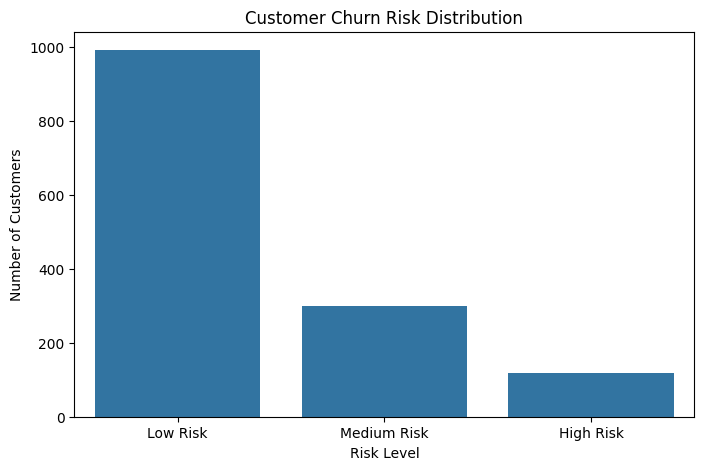

In [239]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=risk_distribution.index,
    y=risk_distribution.values
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.show()

In [240]:
risk_profile = (
    risk_df.groupby("RiskLevel")
    .agg(
        customers=("RiskLevel", "count"),
        avg_tenure=("tenure", "mean"),
        avg_monthly_charges=("MonthlyCharges", "mean"),
        avg_total_charges=("TotalCharges", "mean"),
        actual_churn_rate=("ActualChurn", "mean")
    )
    .sort_values(
        "actual_churn_rate",
        ascending=False
    )
)

risk_profile

,customers,avg_tenure,avg_monthly_charges,avg_total_charges,actual_churn_rate
RiskLevel,,,,,
High Risk,118,4.796610,82.299576,425.105508,0.745763
Medium Risk,300,16.460000,75.520000,1449.960333,0.513333
Low Risk,991,39.823411,58.459990,2648.346711,0.133199


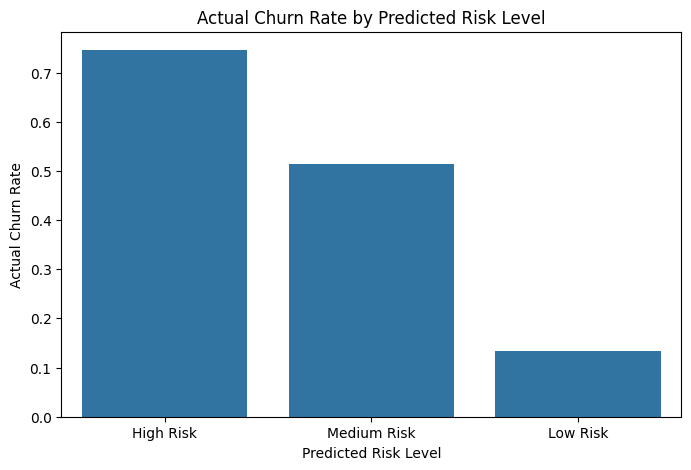

In [241]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_profile.reset_index(),
    x="RiskLevel",
    y="actual_churn_rate"
)

plt.title("Actual Churn Rate by Predicted Risk Level")
plt.xlabel("Predicted Risk Level")
plt.ylabel("Actual Churn Rate")

plt.show()

In [242]:
final_model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision,
        tuned_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall,
        tuned_recall
    ],
    "F1": [
        f1,
        rf_f1,
        xgb_f1,
        tuned_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_auc,
        xgb_auc,
        tuned_auc
    ]
})

final_model_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.800568,0.653465,0.529412,0.584934,0.841853
1,Random Forest,0.778566,0.605442,0.475936,0.532934,0.825428
2,XGBoost,0.799148,0.656357,0.510695,0.574436,0.841564
3,Tuned Logistic Regression,0.801987,0.654723,0.537433,0.590308,0.840928


In [243]:
final_model_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.800568,0.653465,0.529412,0.584934,0.841853
1,Random Forest,0.778566,0.605442,0.475936,0.532934,0.825428
2,XGBoost,0.799148,0.656357,0.510695,0.574436,0.841564
3,Tuned Logistic Regression,0.801987,0.654723,0.537433,0.590308,0.840928


In [244]:
cm_final = confusion_matrix(
    y_test,
    y_pred_final
)

print("Confusion Matrix:")
print(cm_final)

Confusion Matrix:
[[778 257]
 [ 95 279]]


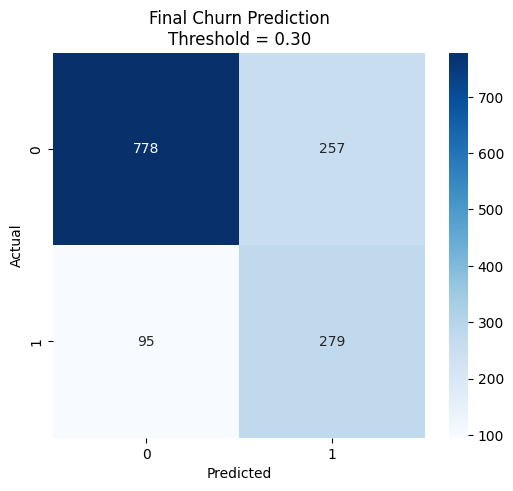

In [245]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Final Churn Prediction\nThreshold = 0.30"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Key Findings

### 1. Customer Churn Rate

The dataset contains 7,043 customers, with 1,869 customers classified as churned and 5,174 customers as non-churned.

This indicates that approximately 26.54% of customers in the dataset churned.

### 2. Contract Type is Strongly Associated with Churn

Month-to-month customers had the highest churn rate at approximately 42.71%, while customers with two-year contracts had a much lower churn rate of approximately 2.83%.

This suggests that customers with shorter contractual commitments represent a higher-risk segment.

### 3. Internet Service Shows Different Churn Patterns

Fiber optic customers had a churn rate of approximately 41.89%, compared with 18.96% for DSL customers and 7.41% for customers without internet service.

### 4. Payment Method is Associated with Churn

Electronic check customers showed the highest churn rate at approximately 45.29%, substantially higher than the other payment methods.

### 5. Tenure is an Important Predictor

Permutation importance identified tenure as the most important feature for churn prediction, with an importance score of approximately 0.180.

Customers who churned also tended to have shorter tenure than customers who remained.

### 6. Model Comparison

Logistic Regression performed best among the tested baseline models, achieving approximately 80.06% accuracy and 0.8419 ROC-AUC.

Random Forest performed worse across the main evaluation metrics, while XGBoost achieved performance close to Logistic Regression.

### 7. Threshold Optimization Improved Churn Detection

Using the default threshold of 0.50 resulted in a churn recall of approximately 53.74%.

Reducing the decision threshold to 0.30 increased recall to approximately 74.60%, with an F1-score of approximately 61.32%.

This trade-off increases the number of churn-risk customers detected by the model.

### 8. Risk Segmentation

The final model divided test customers into three risk groups.

High Risk customers had an actual churn rate of approximately 74.58%, Medium Risk customers had an actual churn rate of approximately 51.33%, while Low Risk customers had an actual churn rate of approximately 13.32%.

This demonstrates that the model can provide meaningful customer risk prioritization.

## Conclusion

This project developed a customer churn prediction system using machine learning and a structured data science workflow.

The analysis covered data understanding, exploratory analysis, feature engineering, preprocessing, model comparison, cross-validation, hyperparameter tuning, threshold optimization, feature interpretation, and customer risk profiling.

Logistic Regression provided the strongest overall baseline performance, while the final threshold optimization improved churn recall from approximately 53.74% to 74.60%.

The analysis also identified tenure, internet service, monthly charges, and contract type as important signals in churn prediction.

More importantly, the final model was able to divide customers into High, Medium, and Low Risk groups with clearly different actual churn rates. This transforms the prediction model into a practical decision-support tool that can help businesses prioritize customer retention efforts.